
# Binning and Binarization in Machine Learning

This notebook demonstrates **two important feature engineering techniques**:

1. **Binning (Discretization)**
2. **Binarization**

These techniques are used during **data preprocessing** to simplify numerical features and sometimes improve model performance.


# Import Libraries

In [68]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import KBinsDiscretizer, Binarizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import  DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import  accuracy_score

warnings.filterwarnings("ignore")

# Import Dataset

In this notebook we will use the **Titanic dataset** to demonstrate binning techniques.

We will apply binning on numerical features such as:
- Age
- Fare

These features are continuous and can be transformed into categorical intervals using binning.

In [19]:
df = pd.read_csv("D:\Machine Learning\ML_Preprocessing\Machine_Learning_Pipelines\\train.csv", usecols=["Age",'Fare','Survived'])

df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [20]:
df.dropna(inplace=True)

In [21]:
df.shape

(714, 3)

# Train Test Split

In [22]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [23]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


# Model Implementation

In [25]:
clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [26]:
accuracy_score(y_test,y_pred)

0.6153846153846154

In [27]:
np.mean(cross_val_score(clf,X_train,y_train,cv=10, scoring='accuracy'))

np.float64(0.6253478523895947)

# What is Binning?

**Binning** converts continuous numerical values into **discrete intervals (bins)**.

Instead of working with raw numbers, values are grouped into ranges.

### Example

Age values:

18, 22, 25, 35, 42, 60

After binning:

- Young → 18–25
- Adult → 26–40
- Senior → 41+

### Why Binning is Useful

- Reduces noise in data
- Simplifies complex distributions
- Helps capture non‑linear relationships
- Makes models easier to interpret


## Types of Binning
### 1. Equal Width Binning

Equal width binning divides the data range into intervals of equal size.

This can be implemented using `pd.cut()`.

In [28]:
X['Age_bin_equal_width'] = pd.cut(X['Age'], bins=3)

X[['Age', 'Age_bin_equal_width']].head()

,Age,Age_bin_equal_width
0,22.0,"(0.34, 26.947]"
1,38.0,"(26.947, 53.473]"
2,26.0,"(0.34, 26.947]"
3,35.0,"(26.947, 53.473]"
4,35.0,"(26.947, 53.473]"


### 2. Equal Frequency Binning
Equal Frequency binning ensures that each bin contains approximately the same number of observations.

This can be implemented using `pd.qcut()`.

In [29]:
X['Age_bin_equal_freq'] = pd.qcut(X['Age'], q=3)

X[['Age', 'Age_bin_equal_freq']].head()

,Age,Age_bin_equal_freq
0,22.0,"(0.419, 23.0]"
1,38.0,"(34.0, 80.0]"
2,26.0,"(23.0, 34.0]"
3,35.0,"(34.0, 80.0]"
4,35.0,"(34.0, 80.0]"


### 3. Custom Binning
Sometimes bins are defined manually based on domain knowledge.

For Example:

Age groups :-
-  Child
- Adult
- Senior

In [30]:
bins= [0,18,40,100]
labels = ['Child','Adult','Senior']

X['Age_group'] = pd.cut(X["Age"], bins=bins, labels=labels)

X[["Age", "Age_group"]].sample(5)

,Age,Age_group
265,36.0,Adult
191,19.0,Adult
455,29.0,Adult
361,29.0,Adult
840,20.0,Adult


## KBinsDisretizer
KBinsDisretizer is a Scikit-Learn preprocessing tool that  converts continuous features into discrete bins.

It supports three strategies:
- uniform --> equal width bins
- quantile --> equal frequency bins
- kmeans --> bins based on clustering


In [31]:
kb_uniform = KBinsDiscretizer(n_bins=5, encode='ordinal',strategy='uniform')
kb_quantile   = KBinsDiscretizer(n_bins=5, encode='ordinal',strategy='quantile')
kb_kmeans  = KBinsDiscretizer(n_bins=5, encode='ordinal',strategy='kmeans')


### 1. Uniform Strategy


In [32]:
X['Age_uniform'] = kb_uniform.fit_transform(X[['Age']].fillna(X['Age'].mean()))

X[["Age", "Age_uniform"]].sample(5)

,Age,Age_uniform
378,20.0,1.0
489,9.0,0.0
376,22.0,1.0
854,44.0,2.0
662,47.0,2.0


If we want to see the intervals/range the we use `bins_edges_`.

The `bins_edges_` attributes of `KBinsDiscretize` stores the boundaries of each bin. These boundaries can be used to create human-readable interval labels with their starting points,

In [33]:
edges = kb_uniform.bin_edges_[0]
print("Bin Intervals of kb_uniform")
for i in range(len(edges)-1):
    print(f"{edges[i]:.2f} - {edges[i+1]:.2f}")

Bin Intervals of kb_uniform
0.42 - 16.34
16.34 - 32.25
32.25 - 48.17
48.17 - 64.08
64.08 - 80.00


### 2. Quantile Strategy

In [34]:
X["Age_quantile"] = kb_quantile.fit_transform(X[['Age']].fillna(X['Age'].mean()))

X[["Age", "Age_quantile"]].sample(5)

,Age,Age_quantile
566,19.0,1.0
730,29.0,2.0
471,38.0,3.0
7,2.0,0.0
728,25.0,2.0


In [35]:
edges = kb_quantile.bin_edges_[0]
print("Bin Intervals of kb_quantile")
for i in range(len(edges)-1):
    print(f"{edges[i]:.2f} - {edges[i+1]:.2f}")

Bin Intervals of kb_quantile
0.42 - 19.00
19.00 - 25.00
25.00 - 31.80
31.80 - 41.00
41.00 - 80.00


### 3. Kmeans Strategy

In [36]:
X["Age_kmeans"] = kb_kmeans.fit_transform(X[['Age']].fillna(X['Age'].mean()))

X[["Age", "Age_kmeans"]].sample(5)

,Age,Age_kmeans
120,21.0,1.0
493,71.0,4.0
842,30.0,2.0
668,43.0,3.0
217,42.0,3.0


In [37]:
edges = kb_kmeans.bin_edges_[0]
print("Bin Intervals of kb_kmeans")
for i in range(len(edges)-1):
    print(f"{edges[i]:.2f} - {edges[i+1]:.2f}")

Bin Intervals of kb_kmeans
0.42 - 13.16
13.16 - 27.01
27.01 - 39.40
39.40 - 54.04
54.04 - 80.00


## Model implementation
So we create a function which contains **KBinsDiscretizer, columntransformer, cross_val_score, and visualizaation**

In [61]:
def discritize(bins, strategy):

    kbins_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbins_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer(
        transformers=[
            ('first', kbins_age, [0]),
            ('second', kbins_fare, [1])
        ]
    )

    X_trf = trf.fit_transform(X_train)

    print(np.mean(cross_val_score(DecisionTreeClassifier(), X_trf, y_train, cv=10, scoring='accuracy')))

    cols = ['Age','Fare']

    for i, col in enumerate(cols):

        plt.figure(figsize=(14,4))

        plt.subplot(1,2,1)
        plt.hist(X_train[col])
        plt.title("Before")

        plt.subplot(1,2,2)
        plt.hist(X_trf[:, i], color='red')
        plt.title("After")

        plt.show()

we call that function with different strategy for understanding all techniques and how it effect on the data/ features.

0.6777979431336962


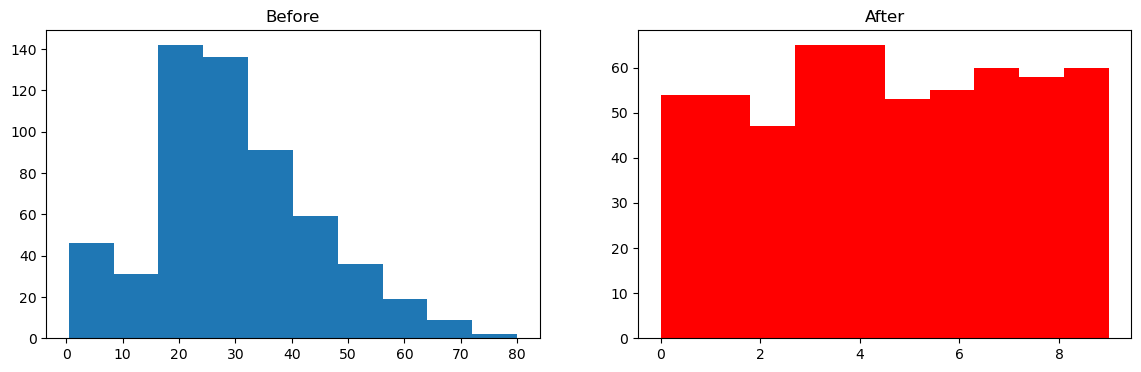

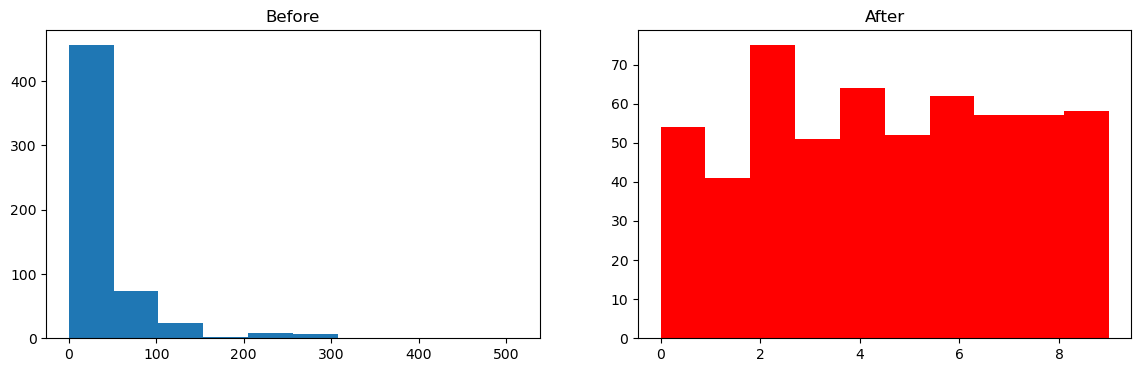

In [65]:
discritize(10,'quantile')

0.6374470659407139


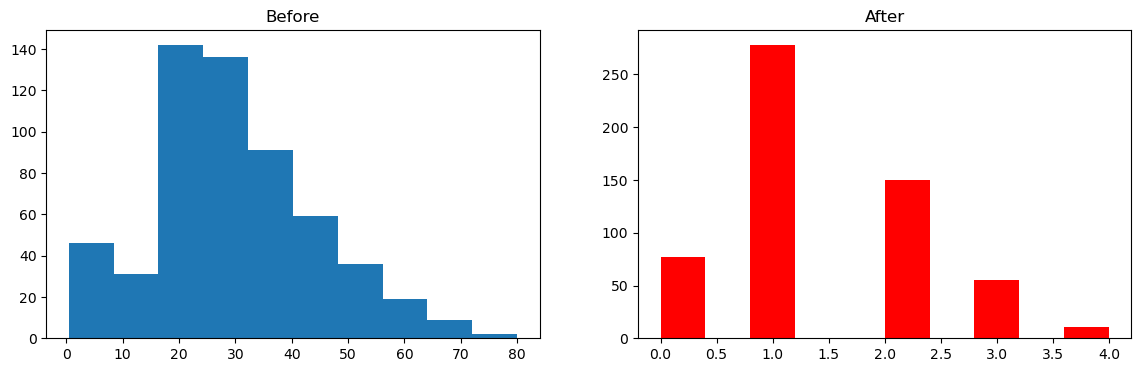

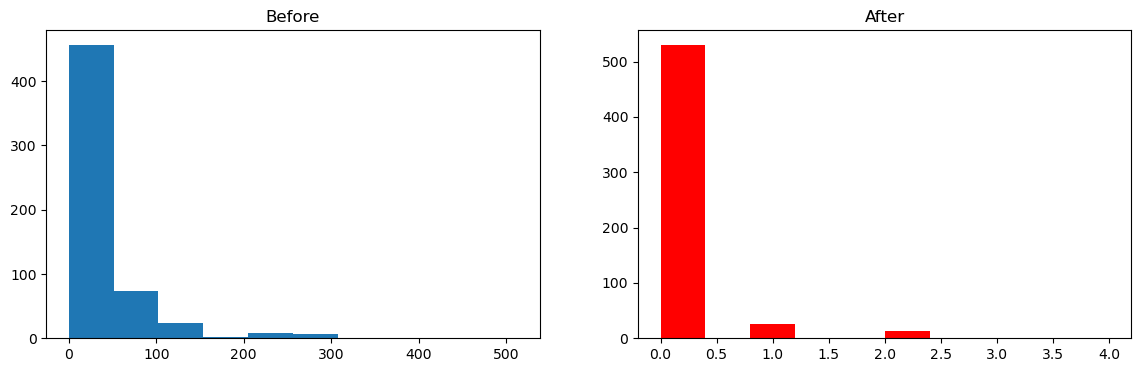

In [66]:
discritize(5,'uniform')

0.6881730187537809


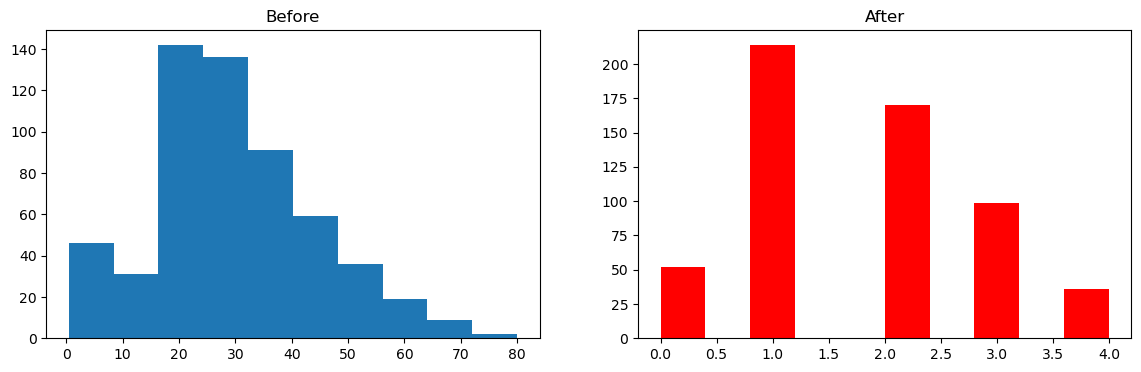

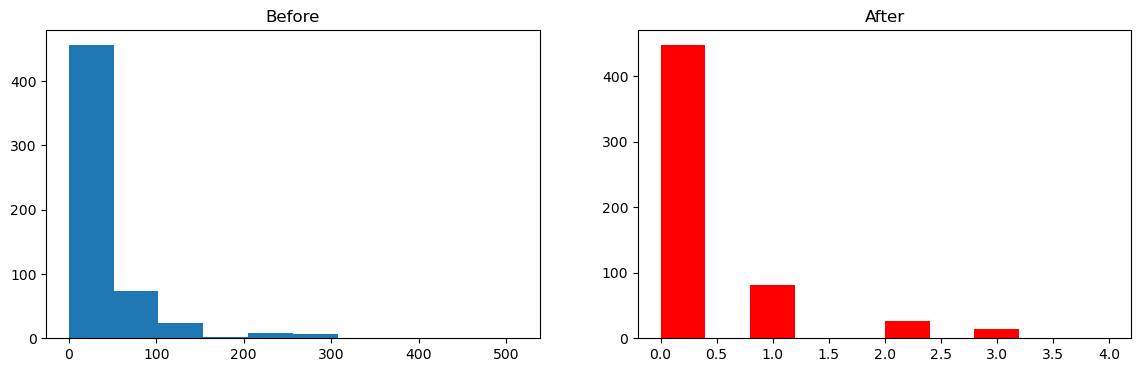

In [67]:
discritize(5,'kmeans')

### Observation
So the `cross_val_score :` is *0.6253* without Binning

the `cross_val_score :` after binning on different strategy are
- uniform : 0.6374
- kmeans : 0.6881
- quantity : 0.6777

# What is Binarization ?
**Binarization** converts numerical values into **binary values (0 or 1)** based on a threshold.
Values above the threshold become 1, and values below the threshold become 0.

- So firstly we copy `df` into a new DataFrame to making notebook clean, and then separate the featues and target.


In [72]:
df_b = df.copy()

Xb = df_b.iloc[:,1:]
yb = df_b.iloc[:,0]

## Binarization Example (Threshold based)

In [74]:
binarizer = Binarizer(threshold=30)

Xb["Age"] = binarizer.fit_transform(Xb[["Age"]])

**observation : we observe that after the binarization on `Age` column we get two value 0 and 1. So the age greater than 30 come under 1 category and rest all or say that less than comes under 30**

In [76]:
Xb["Age"].value_counts()

Age
0.0    409
1.0    305
Name: count, dtype: int64